In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()  # This opens a file upload dialog



Saving College_admission.csv to College_admission.csv


In [ ]:
import pandas as pd

df = pd.read_csv("College_admission.csv")
df.head()
df.tail()
df.shape

(400, 7)

In [ ]:
df.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,0,380,3.61,1,0,3,3
1,1,660,3.67,2,0,2,3
2,1,800,4.00,2,0,2,1
3,1,640,3.19,1,1,2,4
4,0,520,2.93,3,1,2,4


In [ ]:
# Check for missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())



admit          0
gre            0
gpa            0
ses            0
Gender_Male    0
Race           0
rank           0
dtype: int64
            admit         gre         gpa         ses  Gender_Male  \
count  400.000000  400.000000  400.000000  400.000000      400.000   
mean     0.317500  587.700000    3.389900    1.992500        0.475   
std      0.466087  115.516536    0.380567    0.808751        0.500   
min      0.000000  220.000000    2.260000    1.000000        0.000   
25%      0.000000  520.000000    3.130000    1.000000        0.000   
50%      0.000000  580.000000    3.395000    2.000000        0.000   
75%      1.000000  660.000000    3.670000    3.000000        1.000   
max      1.000000  800.000000    4.000000    3.000000        1.000   

             Race       rank  
count  400.000000  400.00000  
mean     1.962500    2.48500  
std      0.823279    0.94446  
min      1.000000    1.00000  
25%      1.000000    2.00000  
50%      2.000000    2.00000  
75%      3.000000   

In [ ]:


# Check for missing values
print(df.isnull().sum())


admit          0
gre            0
gpa            0
ses            0
Gender_Male    0
Race           0
rank           0
dtype: int64


<ipython-input-27-143c114ee59d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='admit', data=df, palette='Set2')


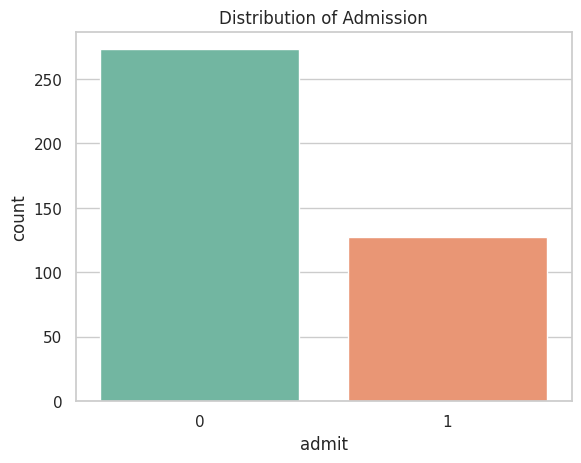

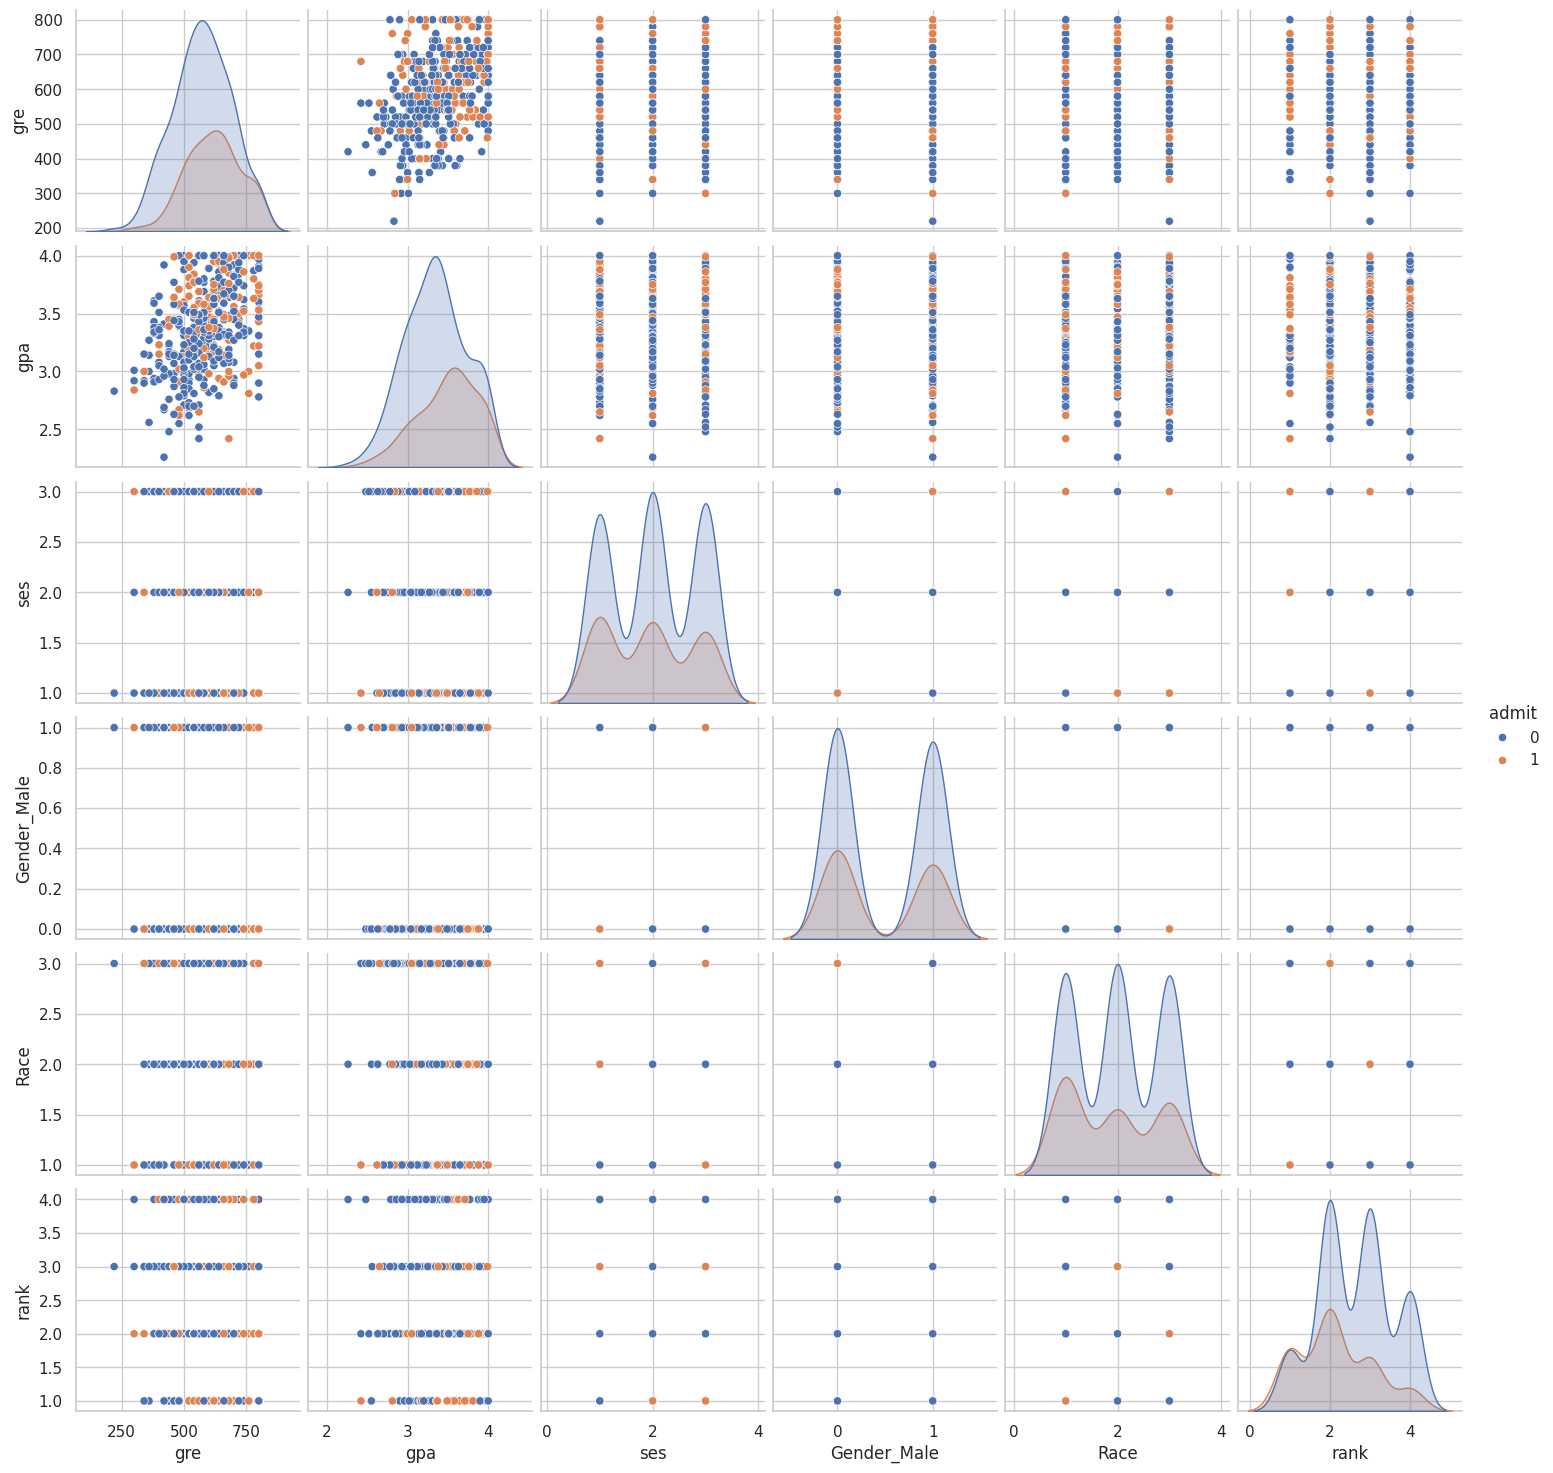

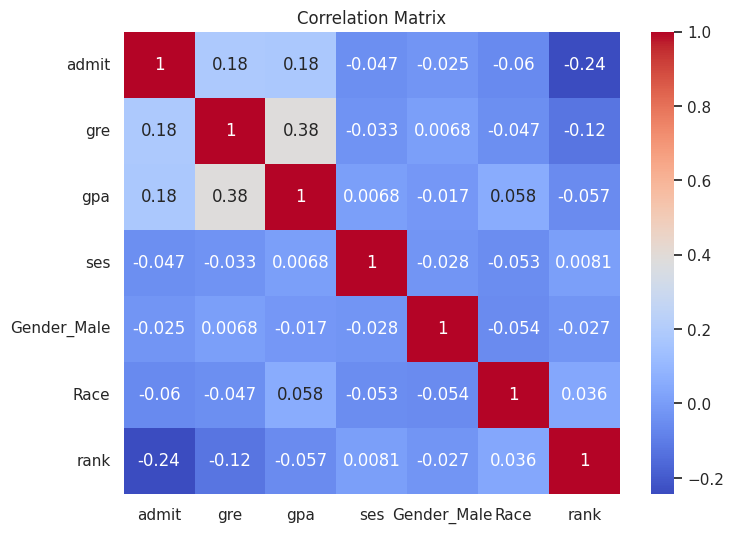

In [ ]:
# Target variable distribution
sns.countplot(x='admit', data=df, palette='Set2')
plt.title("Distribution of Admission")
plt.show()

# Pairplot of numerical features
sns.pairplot(df, hue='admit', diag_kind='kde')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


<ipython-input-33-8b845ef43b08>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='admit', data=df, palette='Set2')


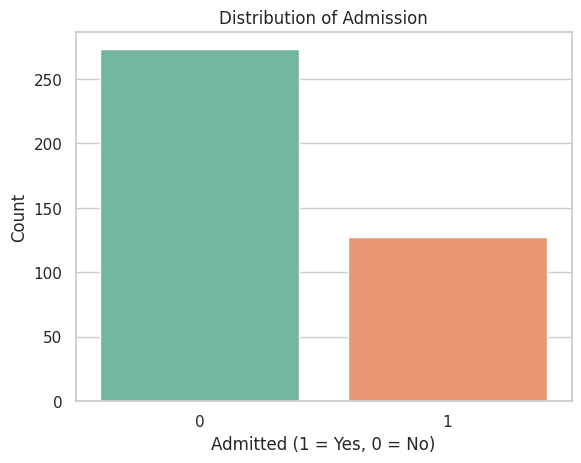

Admission Rates:
 admit
0    68.25
1    31.75
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='admit', data=df, palette='Set2')
plt.title("Distribution of Admission")
plt.xlabel("Admitted (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# Percentages
admit_rate = df['admit'].value_counts(normalize=True) * 100
print("Admission Rates:\n", admit_rate)


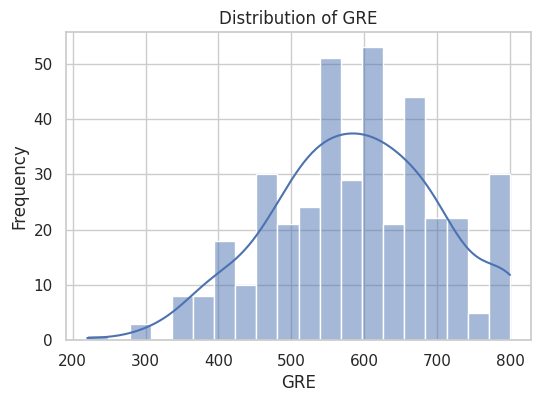

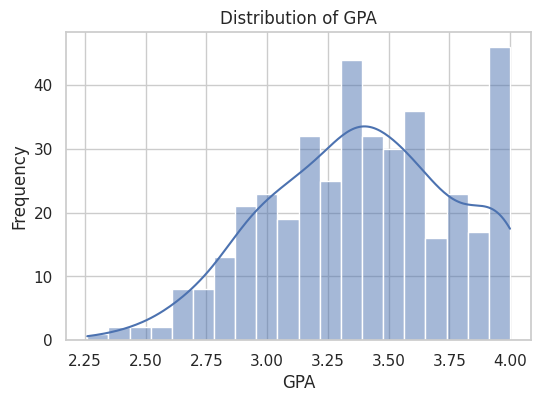

In [ ]:
num_cols = ['gre', 'gpa']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col.upper()}')
    plt.xlabel(col.upper())
    plt.ylabel('Frequency')
    plt.show()


<ipython-input-35-73f09c89a64d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='admit', y=col, data=df, palette='pastel')


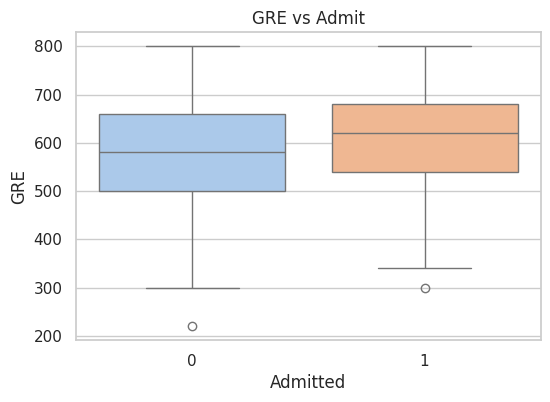

<ipython-input-35-73f09c89a64d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='admit', y=col, data=df, palette='pastel')


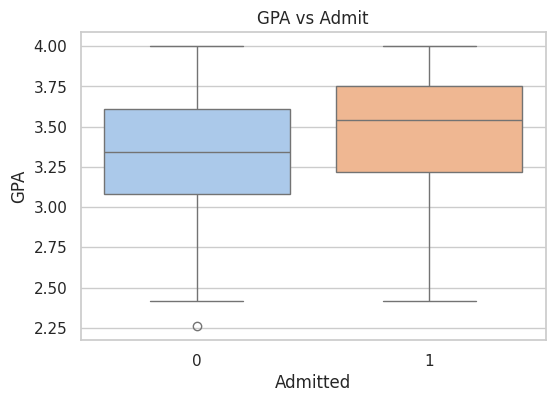

In [ ]:
for col in ['gre', 'gpa']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='admit', y=col, data=df, palette='pastel')
    plt.title(f'{col.upper()} vs Admit')
    plt.xlabel("Admitted")
    plt.ylabel(col.upper())
    plt.show()


In [ ]:
# Define independent variables (features) and target
X = df.drop('admit', axis=1)
y = df['admit']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Initialize and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Accuracy: 0.6625


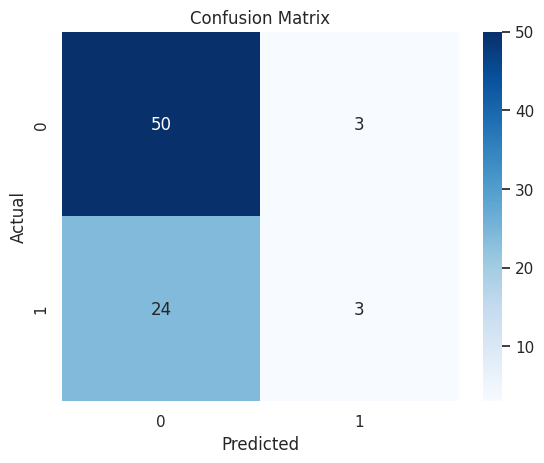

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.94      0.79        53
           1       0.50      0.11      0.18        27

    accuracy                           0.66        80
   macro avg       0.59      0.53      0.48        80
weighted avg       0.62      0.66      0.58        80



In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))



In [ ]:
# Perform cross-validation
scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5)
print("Cross-Validation Scores:", scores)
print("Average CV Accuracy:", scores.mean())



Cross-Validation Scores: [0.7    0.75   0.6875 0.6375 0.6625]
Average CV Accuracy: 0.6875000000000001


In [ ]:
# Perform cross-validation
scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5)
print("Cross-Validation Scores:", scores)
print("Average CV Accuracy:", scores.mean())


Cross-Validation Scores: [0.7    0.75   0.6875 0.6375 0.6625]
Average CV Accuracy: 0.6875000000000001
